In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from tensorflow.keras import backend as K
from keras.preprocessing.image import ImageDataGenerator, load_img
import os, random
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation
from matplotlib import animation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Dense, Flatten, BatchNormalization, Conv2D, MaxPool2D
import cv2
import tensorflow as tf
from keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import classification_report,confusion_matrix
import ffmpy
import ffmpeg

In [ ]:
labels = ['PNEUMONIA', 'NORMAL']
img_size = 150
def get_training_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_arr = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_arr = cv2.resize(img_arr, (img_size, img_size)) # Reshaping images to preferred size
                data.append([resized_arr, class_num])
            except Exception as e:
                print(e)
    return np.array(data)

In [ ]:
train = get_training_data('/Users/malliksiddarth/Downloads/chest_xray/train')
test = get_training_data('/Users/malliksiddarth/Downloads/chest_xray/test')
val = get_training_data('/Users/malliksiddarth/Downloads/chest_xray/val')

OpenCV(4.5.5) /Users/runner/work/opencv-python/opencv-python/opencv/modules/imgproc/src/resize.cpp:4052: error: (-215:Assertion failed) !ssize.empty() in function 'resize'



<ipython-input-2-b2613b36a4a4>:15: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return np.array(data)


OpenCV(4.5.5) /Users/runner/work/opencv-python/opencv-python/opencv/modules/imgproc/src/resize.cpp:4052: error: (-215:Assertion failed) !ssize.empty() in function 'resize'

OpenCV(4.5.5) /Users/runner/work/opencv-python/opencv-python/opencv/modules/imgproc/src/resize.cpp:4052: error: (-215:Assertion failed) !ssize.empty() in function 'resize'



/opt/anaconda3/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:ylabel='count'>

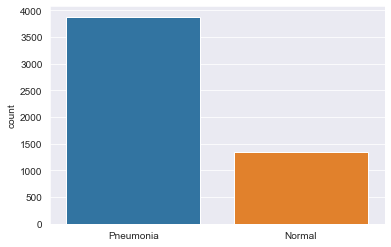

In [ ]:
l = []
for i in train:
    if(i[1] == 0):
        l.append("Pneumonia")
    else:
        l.append("Normal")
sns.set_style('darkgrid')
sns.countplot(l)

Printing three Normal random images 
NORMAL2-IM-0302-0001.jpeg
NORMAL2-IM-0051-0001.jpeg
NORMAL2-IM-0279-0001.jpeg


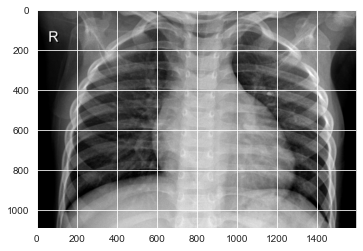

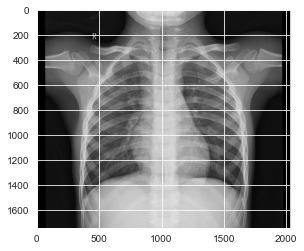

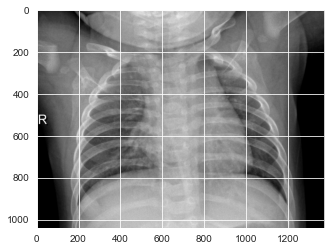

In [ ]:
# Three Random Normal CXR Images from the dataset
import os, random

folder_N=('/Users/malliksiddarth/Downloads/chest_xray/test/NORMAL')

a=random.choice(os.listdir(folder_N))
b=random.choice(os.listdir(folder_N))
c=random.choice(os.listdir(folder_N))
print("Printing three Normal random images ")
print(a)
print(b)
print(c)

random_N = [a, b, c]

for i in random_N:
    file = folder_N+'/'+i
    img = image.load_img(file)
    plt.figure()
    plt.imshow(img)
    plt.show()

In [ ]:
x_train = []
y_train = []

x_val = []
y_val = []

x_test = []
y_test = []

for feature, label in train:
    x_train.append(feature)
    y_train.append(label)

for feature, label in test:
    x_test.append(feature)
    y_test.append(label)

for feature, label in val:
    x_val.append(feature)
    y_val.append(label)

In [ ]:
# Normalize the data
x_train = np.array(x_train) / 255
x_val = np.array(x_val) / 255
x_test = np.array(x_test) / 255

In [ ]:
# resize data for deep learning
x_train = x_train.reshape(-1, img_size, img_size, 1)
y_train = np.array(y_train)

x_val = x_val.reshape(-1, img_size, img_size, 1)
y_val = np.array(y_val)

x_test = x_test.reshape(-1, img_size, img_size, 1)
y_test = np.array(y_test)

In [ ]:
# With data augmentation to prevent overfitting and handling the imbalance in dataset

datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range = 30,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.2, # Randomly zoom image
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip = True,  # randomly flip images
        vertical_flip=False)  # randomly flip images


datagen.fit(x_train)

In [ ]:
model = Sequential()
model.add(Conv2D(32 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu' , input_shape = (150,150,1)))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(64 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.1))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(64 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(128 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(256 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Flatten())
model.add(Dense(units = 128 , activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(units = 1 , activation = 'sigmoid'))
model.compile(optimizer = "rmsprop" , loss = 'binary_crossentropy' , metrics = ['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      320       
                                                                 
 batch_normalization (BatchN  (None, 150, 150, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 75, 75, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 75, 75, 64)        18496     
                                                                 
 dropout (Dropout)           (None, 75, 75, 64)        0         
                                                                 
 batch_normalization_1 (Batc  (None, 75, 75, 64)       2

In [ ]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience = 2, verbose=1,factor=0.3, min_lr=0.000001)

In [ ]:
history = model.fit(datagen.flow(x_train,y_train, batch_size = 32) ,epochs = 12 , validation_data = datagen.flow(x_val, y_val) ,callbacks = [learning_rate_reduction])

Epoch 1/12
164/164 [==============================] - 109s 656ms/step - loss: 0.5608 - accuracy: 0.8293 - val_loss: 15.4381 - val_accuracy: 0.5000 - lr: 0.0010
Epoch 2/12
164/164 [==============================] - 115s 702ms/step - loss: 0.2777 - accuracy: 0.8901 - val_loss: 54.1687 - val_accuracy: 0.5000 - lr: 0.0010
Epoch 3/12
164/164 [==============================] - ETA: 0s - loss: 0.2363 - accuracy: 0.9170
Epoch 00003: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
164/164 [==============================] - 109s 663ms/step - loss: 0.2363 - accuracy: 0.9170 - val_loss: 42.2810 - val_accuracy: 0.5000 - lr: 0.0010
Epoch 4/12
164/164 [==============================] - 108s 659ms/step - loss: 0.1627 - accuracy: 0.9451 - val_loss: 0.5824 - val_accuracy: 0.6875 - lr: 3.0000e-04
Epoch 5/12
164/164 [==============================] - 109s 666ms/step - loss: 0.1536 - accuracy: 0.9474 - val_loss: 1.1599 - val_accuracy: 0.5625 - lr: 3.0000e-04
Epoch 6/12
164/164 [=========

In [ ]:
print("Loss of the model is - " , model.evaluate(x_test,y_test)[0])
print("Accuracy of the model is - " , model.evaluate(x_test,y_test)[1]*100 , "%")

20/20 [==============================] - 4s 204ms/step - loss: 0.2921 - accuracy: 0.9071
Loss of the model is -  0.29212120175361633
20/20 [==============================] - 4s 201ms/step - loss: 0.2921 - accuracy: 0.9071
Accuracy of the model is -  90.70512652397156 %


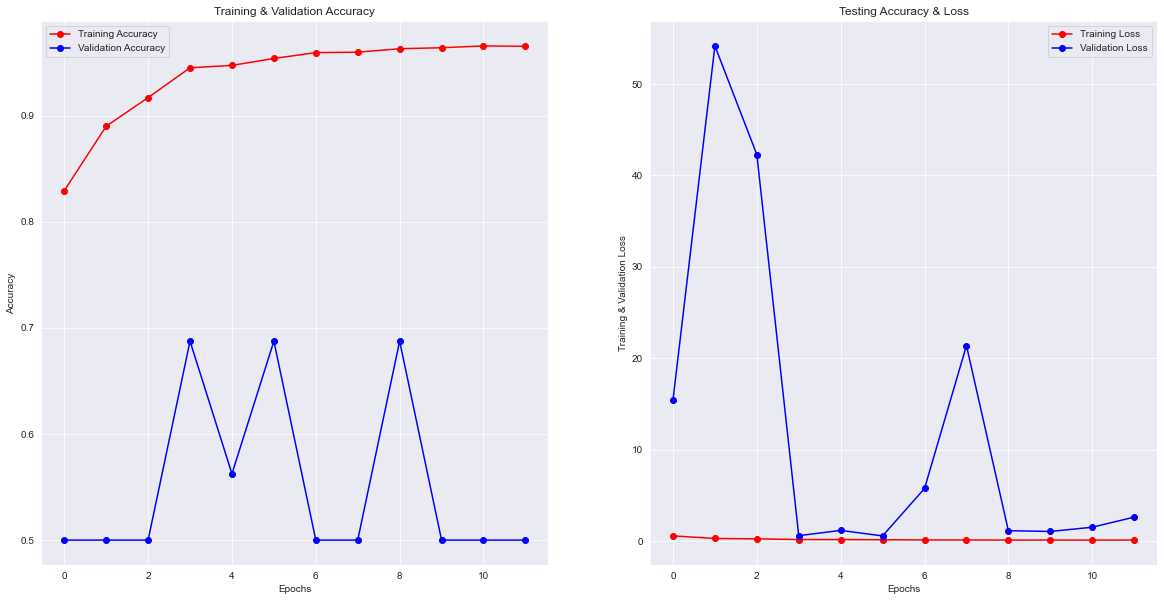

In [ ]:
epochs = [i for i in range(12)]
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
fig.set_size_inches(20,10)

ax[0].plot(epochs , train_acc , 'ro-' , label = 'Training Accuracy')
ax[0].plot(epochs , val_acc , 'bo-' , label = 'Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs , train_loss , 'r-o' , label = 'Training Loss')
ax[1].plot(epochs , val_loss , 'b-o' , label = 'Validation Loss')
ax[1].set_title('Testing Accuracy & Loss')
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Training & Validation Loss")
plt.show()

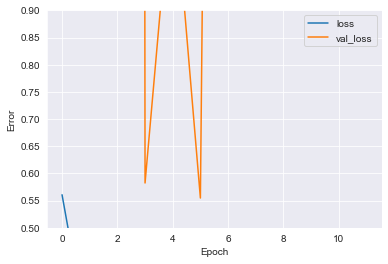

In [ ]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

def plot_loss(history):
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.ylim([0.5, 0.9])
    plt.xlabel('Epoch')
    plt.ylabel('Error')
    plt.legend()
    plt.grid(True)

plot_loss(history)

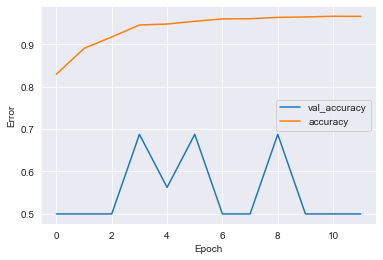

In [ ]:
def plot_loss(history):
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Error')
    plt.legend()
    plt.grid(True)
    plt.pause(0.01)

plot_loss(history)

RuntimeError: Requested MovieWriter (ffmpeg) not available

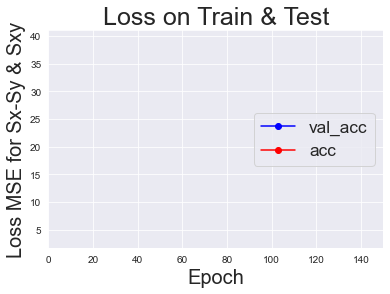

In [ ]:
def animate(i, val_accuracy, accuracy, line1, line2):
    temp1 = val_accuracy.iloc[:int(i+1)]
    temp2 = accuracy.iloc[:int(i+1)]

    line1.set_data(temp1.index, temp1.value)
    line2.set_data(temp2.index, temp2.value)

    return (line1, line2)


def create_loss_animation(model_type, val_accuracy, accuracy):
    fig = plt.figure()
    plt.title(f'Loss on Train & Test', fontsize=25)
    plt.xlabel('Epoch', fontsize=20)
    plt.ylabel('Loss MSE for Sx-Sy & Sxy', fontsize=20)
    plt.xlim(min(val_accuracy.index.min(), accuracy.index.min()), max(val_accuracy.index.max(), accuracy.index.max()))
    plt.ylim(min(accuracy.value.min(), accuracy.value.min()), max(val_accuracy.value.max(), accuracy.value.max()))

    l1, = plt.plot([], [], 'o-', label='val_acc', color='b', markevery=[-1])
    l2, = plt.plot([], [], 'o-', label='acc', color='r', markevery=[-1])
    plt.legend(loc='center right', fontsize='xx-large')

    Writer = animation.writers['ffmpeg']
    writer = Writer(fps=5, bitrate=1800)

    ani = matplotlib.animation.FuncAnimation(fig, animate, fargs=(accuracy, accuracy, l1, l2), repeat=True, interval=1000, repeat_delay=1000)
    ani.save(f'{model_type}.mp4', writer=writer)

# create datasets
x = np.linspace(0,150,50)
y1 = 41*np.exp(-x/20)
y2 = 35*np.exp(-x/50)

my_data_number_1 = pd.DataFrame({'x':x, 'value':y1}).set_index('x')
my_data_number_2 = pd.DataFrame({'x':x, 'value':y2}).set_index('x')

create_loss_animation('test', my_data_number_1, my_data_number_2)

In [ ]:
predictions = model.predict(x_test)
predictions = predictions.reshape(1,-1)[0]
predictions[:15]

array([9.9294148e-06, 1.8116491e-09, 1.2141287e-02, 7.8898603e-15,
       4.0868461e-02, 4.4812799e-02, 2.0188758e-01, 2.3475397e-01,
       4.0806896e-21, 4.4294711e-17, 5.7736039e-04, 2.7342219e-17,
       1.9617577e-05, 9.5536649e-02, 7.3340535e-04], dtype=float32)

In [ ]:
print(classification_report(y_test, predictions, target_names = ['Pneumonia (Class 0)','Normal (Class 1)']))

ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [ ]:
correct = np.nonzero(predictions == y_test)[0]
incorrect = np.nonzero(predictions != y_test)[0]

In [ ]:
i = 0
for c in correct[:6]:
    plt.subplot(3,2,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[c].reshape(150,150), cmap="gray", interpolation='none')
    plt.title("Predicted Class {},Actual Class {}".format(predictions[c], y_test[c]))
    plt.tight_layout()
    i += 1

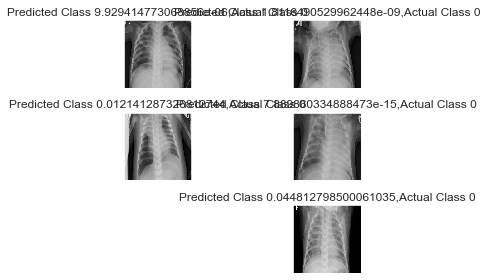

In [ ]:
i = 0
for c in incorrect[:6]:
    plt.subplot(3,2,i+1)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(x_test[c].reshape(150,150), cmap="gray", interpolation='none')

    plt.title("Predicted Class {},Actual Class {}".format(predictions[c], y_test[c]))

    plt.tight_layout()
    i += 1